## Buscar kerner

In [13]:
#Librerias

#pandas: Estructuras de datos y análisis de datos (ideal para leer y manipular archivos CSV como tablas).
import pandas as pd

#spacy: Procesamiento de Lenguaje Natural (NLP) avanzado, usado para entender gramática, lematizar o eliminar "stop words".
import spacy

#re: Expresiones regulares, utilizado para encontrar y manipular patrones de texto específicos (como detectar URLs o números).
import re

#numpy: Computación científica y operaciones matemáticas de alto rendimiento con arreglos (arrays) y matrices.
import numpy as np

#matplotlib.pyplot: Creación de gráficos y visualizaciones de datos estáticas, animadas e interactivas en 2D.
import matplotlib.pyplot as plt

#matplotlib.patches: Creación de formas geométricas y elementos visuales personalizados para los gráficos (muy útil para leyendas complejas).
import matplotlib.patches as mpatches

#time: Proporciona funciones relacionadas con el tiempo (por ejemplo, para medir exactamente cuántos segundos tarda en entrenar cada kernel).
import time

#warnings: Controla los mensajes de advertencia de Python; aquí se configura para ignorar avisos no críticos y mantener la consola limpia.
import warnings
warnings.filterwarnings('ignore')

#sklearn.model_selection (train_test_split): Divide tu conjunto de datos original en dos partes: una para entrenar el modelo y otra para evaluarlo de forma justa.
from sklearn.model_selection import train_test_split

#sklearn.feature_extraction.text (TfidfVectorizer): Transforma los mensajes de texto en vectores matemáticos, dándole más peso a las palabras raras e importantes.
from sklearn.feature_extraction.text import TfidfVectorizer

#sklearn.svm (SVC): Es el corazón de tu código; el algoritmo clasificador de Máquinas de Vectores de Soporte (Support Vector Classification), que permite usar diferentes "kernels".
from sklearn.svm import SVC

#sklearn.metrics: Colección de fórmulas para calificar tu modelo comparando sus predicciones con la realidad (exactitud, exhaustividad, puntuación F1, etc.).
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

#sklearn.decomposition (TruncatedSVD): Técnica matemática que "aplasta" datos de miles de dimensiones en solo 2 o 3 para que puedas dibujarlos en una gráfica (ideal para TF-IDF).
from sklearn.decomposition import TruncatedSVD

#scipy.sparse (hstack): Función que permite pegar o "apilar" horizontalmente matrices llenas de ceros (dispersas) de manera muy eficiente en la memoria de la computadora.
from scipy.sparse import hstack

In [14]:
#Carga del modelo es_core_news
print("Cargando spaCy...")
nlp = spacy.load("es_core_news_sm")

Cargando spaCy...


In [15]:
#Proceso de limpieza de texto
def limpiar_texto(texto):
    #Se realiza una limipieza del texto, como:
    #Convierte el texto a minúsculas.
    texto = str(texto).lower()
    #Elimina URLs y reemplaza por un token específico para mantener la información de que había una URL sin conservar la URL en sí.
    texto = re.sub(r'(https?://\S+|www\.\S+)', ' tokenurl ', texto)
    #Elimina direcciones de correo electrónico y reemplaza por un token específico para mantener la información de que había un correo sin conservar el correo en sí.
    texto = re.sub(r"\S+@\S+\.\S+", " tokencorreo ", texto)
    #Reemplaza números grandes, medianos y pequeños por tokens específicos para mantener la información de que había números sin conservar los números en sí.
    texto = re.sub(r"\b\d{5,}\b", " tokennumero_grande ", texto)
    texto = re.sub(r"\b\d{2,4}\b", " tokennumero_medio ", texto)
    texto = re.sub(r"\b\d\b", " tokennumero_pequeno ", texto)
    #texto = re.sub(r"[@#]\w+", " ", texto)
    #ACTUALIZADO: En lugar de eliminar completamente las palabras que comienzan con @ o #, solo eliminamos los símbolos pero mantenemos las palabras.
    #Solo borra los símbolos @ y #, pero deja las palabras intactas
    texto = re.sub(r"[@#]", " ", texto)
    #Elimina caracteres especiales, pero permite conservar los signos de exclamación, el símbolo de dólar y los espacios, ya que pueden ser relevantes para la detección de spam.
    texto = re.sub(r"[^a-záéíóúüñ0-9!$ ]", " ", texto)
    #Elimina espacios adicionales
    doc = nlp(texto)
    #Agregamos 'and not token.is_stop' para filtrar las palabras vacías
    tokens = [token.text for token in doc if not token.is_space and not token.is_stop]
    #Returnamos el texto limpio y tokenizado como una cadena de texto unida por espacios, ya que el vectorizador TF-IDF espera texto en formato de cadena.
    return " ".join(tokens)

#Función para extraer características manuales del mensaje original (antes de limpiar)
#Esto lo usamos para capturar información que podría perderse en la limpieza, como la presencia de URLs, números, signos de exclamación, etc.
def extraer_features(texto):
    #Convertimos el texto a string por si acaso viene en otro formato (aunque debería ser string, esto es una medida de seguridad).
    texto = str(texto)
    #Calculamos la longitud total del mensaje, el número de palabras, el número de dígitos, 
    # la cantidad de URLs (basado en el token que usamos para reemplazar las URLs), 
    # la cantidad de signos de exclamación y la cantidad de símbolos de dólar.
    longitud = len(texto)
    num_palabras = len(texto.split())
    num_numeros = len(re.findall(r'\d', texto))
    num_urls = texto.count("tokenurl")
    num_exclamaciones = texto.count("!")
    num_dolar = texto.count("$")
    #Retornamos estas caracteristicas
    return [longitud, num_palabras, num_numeros, num_urls, num_exclamaciones, num_dolar]


In [16]:
#Lectura del centro de datos
print("Leyendo centro de datos...")
ruta_csv = "../datos/dataset_spam_modelo.csv" 
#Lectura
df = pd.read_csv(ruta_csv)
#Limpiamos el dataset eliminando filas con mensajes vacíos o etiquetas faltantes, y eliminamos mensajes duplicados para evitar sesgos en el entrenamiento del modelo.
df = df.dropna(subset=['mensaje', 'etiqueta'])
df = df.drop_duplicates(subset=['mensaje'])
#Imprime el número total de mensajes en el dataset después de la limpieza, así como el conteo de cada etiqueta (spam vs ham) para entender la distribución de clases.
print(f"Dataset: {len(df)} mensajes | {df['etiqueta'].value_counts().to_dict()}")

Leyendo centro de datos...
Dataset: 2017 mensajes | {'ham': 1033, 'spam': 984}


In [17]:
#Realiza la separacion de los datos en conjuntos de entrenamiento y prueba
X_raw, y = df['mensaje'], df['etiqueta']
#Utilizamos una semilla, para que los resultados sean similares a lo documentado
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

#Limpieza de texto y extracción de características manuales
print("Limpiando textos...")
X_train_clean = X_train_raw.apply(limpiar_texto)
X_test_clean  = X_test_raw.apply(limpiar_texto)
#Eliminar vacíos
mask_tr = X_train_clean.str.strip() != ""
X_train_clean, y_train, X_train_raw = X_train_clean[mask_tr], y_train[mask_tr], X_train_raw[mask_tr]
mask_te = X_test_clean.str.strip() != ""
X_test_clean, y_test, X_test_raw = X_test_clean[mask_te], y_test[mask_te], X_test_raw[mask_te]

#Obtenemos los Features manuales
feat_train = np.array([extraer_features(t) for t in X_train_raw])
feat_test  = np.array([extraer_features(t) for t in X_test_raw])

#Se realiza la vectorizacion de los textos limpios utilizando TF-IDF, 
# y luego se combinan estos vectores con las características manuales utilizando hstack 
# para crear las matrices finales de entrenamiento y prueba.
print("Vectorizando...")
vec = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.9, ngram_range=(1, 3))
X_tr = hstack([vec.fit_transform(X_train_clean), feat_train])
X_te = hstack([vec.transform(X_test_clean),  feat_test])

#CONFIGURACION DE LOS 4 KERNELS A COMPARAR
#Cada kernel tiene su propia configuración de hiperparámetros, aunque como base se intenta que todos tengan C=1, 
# probability=True y class_weight="balanced" para que la comparación sea más justa, 
# pero con sus diferencias específicas en el tipo de kernel y otros hiperparámetros relevantes.
# Además, se incluye una breve descripción de cómo funciona, sus ventajas y desventajas específicas para 
# el contexto de clasificación de texto (spam vs ham).
kernels = [
    {
        "nombre": "linear",
        "config": {"kernel": "linear", "C": 1, "probability": True, "class_weight": "balanced"},
        "descripcion": "Hiperplano recto. Ideal para NLP con alta dimensionalidad.",
        "ventaja": "El ganador absoluto: la mejor precisión (91.9%) y F1-score.",
        "desventaja": "Tiempo de entrenamiento considerablemente mayor (41.7s).",
    },
    {
        "nombre": "rbf",
        "config": {"kernel": "rbf", "C": 1, "gamma": "scale", "probability": True, "class_weight": "balanced"},
        "descripcion": "Fronteras curvas tipo burbuja (Gaussiano).",
        "ventaja": "Entrenamiento casi instantáneo (0.6s).",
        "desventaja": "Rendimiento deficiente (F1: 62.4%), incapaz de separar bien el texto.",
    },
    {
        "nombre": "poly (grado 3)",
        "config": {"kernel": "poly", "degree": 3, "C": 1, "probability": True, "class_weight": "balanced"},
        "descripcion": "Fronteras polinómicas curvas.",
        "ventaja": "Entrenamiento sumamente rápido (0.6s).",
        "desventaja": "Bajo rendimiento (Accuracy: 64.6%), no se adapta a estos datos.",
    },
    {
        "nombre": "sigmoid",
        "config": {"kernel": "sigmoid", "C": 1, "probability": True, "class_weight": "balanced"},
        "descripcion": "Imita una neurona individual.",
        "ventaja": "El tiempo de entrenamiento más rápido de todos (0.5s).",
        "desventaja": "Rendimiento catastrófico (40.5%), peor que elegir al azar.",
    },
]

Limpiando textos...
Vectorizando...


In [18]:
#ENTRENAIMIENTO Y EVALUACION DE LOS KERNELS
print("\n" + "=" * 65)
print("COMPARATIVA DE KERNELS SVM")
print("=" * 65)

#Creamos una lista vacía para almacenar los resultados de cada kernel, incluyendo métricas de rendimiento y tiempos de entrenamiento, que luego se pueden comparar fácilmente.
resultados = []

#Ciclo a través de cada kernel, entrenando el modelo, haciendo predicciones y calculando métricas de rendimiento para cada uno, además de medir el tiempo que tarda en entrenar cada modelo para evaluar la eficiencia.
for k in kernels:
    print(f"\nEntrenando kernel={k['nombre']}...")
    #Medimos el tiempo que tarda en entrenar el modelo con el kernel actual para evaluar su eficiencia.
    t0 = time.time()
    #Creamos el modelo SVC con la configuración específica del kernel actual, lo entrenamos con los datos de entrenamiento y luego calculamos el tiempo que tomó este proceso.
    modelo = SVC(**k["config"])
    modelo.fit(X_tr, y_train)
    t_entrena = time.time() - t0

    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)
    #Calculamos métricas de rendimiento como la precisión en el conjunto de entrenamiento y prueba, 
    # la brecha entre ambas, la puntuación F1 macro, precisión y recall en el conjunto de prueba, 
    # así como la matriz de confusión para obtener los falsos positivos y falsos negativos.
    acc_tr  = accuracy_score(y_train, y_pred_tr) * 100
    acc_te  = accuracy_score(y_test,  y_pred_te) * 100
    f1_te   = f1_score(y_test, y_pred_te, average='macro') * 100
    prec_te = precision_score(y_test, y_pred_te, average='macro') * 100
    rec_te  = recall_score(y_test, y_pred_te, average='macro') * 100
    brecha  = acc_tr - acc_te
    #Se obtiene la matriz de confusión para calcular los falsos positivos (ham clasificado como spam) 
    # y falsos negativos (spam clasificado como ham), 
    # lo cual es crucial para entender el tipo de errores que comete cada kernel, 
    # especialmente en un contexto de clasificación de texto donde ciertos errores 
    # pueden ser más costosos que otros (por ejemplo, clasificar un mensaje legítimo como spam puede ser molesto para el usuario).
    cm      = confusion_matrix(y_test, y_pred_te)
    fp      = cm[0][1]  #ham clasificado como spam
    fn      = cm[1][0]  #spam clasificado como ham

    #Se almacenan los resultados en la lista de resultados, incluyendo todas las métricas calculadas, el tiempo de entrenamiento y la descripción del kernel para facilitar la comparación posterior.
    resultados.append({
        "Kernel":         k["nombre"],
        "Acc. Train %":   round(acc_tr, 2),
        "Acc. Test %":    round(acc_te, 2),
        "Brecha %":       round(brecha, 2),
        "F1 macro %":     round(f1_te, 2),
        "Precisión %":    round(prec_te, 2),
        "Recall %":       round(rec_te, 2),
        "Falsos +":       fp,
        "Falsos -":       fn,
        "Tiempo (s)":     round(t_entrena, 1),
        "descripcion":    k["descripcion"],
        "ventaja":        k["ventaja"],
        "desventaja":     k["desventaja"],
    })

    #Se imprime un resumen de las métricas clave para el kernel actual, incluyendo la precisión en entrenamiento y prueba, la brecha entre ambas, la puntuación F1 macro, los falsos positivos y negativos, y el tiempo que tomó entrenar el modelo con ese kernel.
    print(f"  Train={acc_tr:.2f}% | Test={acc_te:.2f}% | Brecha={brecha:.2f}% | "
          f"F1={f1_te:.2f}% | FP={fp} | FN={fn} | Tiempo={t_entrena:.1f}s")


COMPARATIVA DE KERNELS SVM

Entrenando kernel=linear...
  Train=98.20% | Test=91.29% | Brecha=6.91% | F1=91.29% | FP=16 | FN=19 | Tiempo=39.0s

Entrenando kernel=rbf...
  Train=60.02% | Test=64.43% | Brecha=-4.40% | F1=59.11% | FP=3 | FN=140 | Tiempo=0.6s

Entrenando kernel=poly (grado 3)...
  Train=58.97% | Test=64.68% | Brecha=-5.71% | F1=59.80% | FP=5 | FN=137 | Tiempo=0.6s

Entrenando kernel=sigmoid...
  Train=46.12% | Test=36.32% | Brecha=9.80% | F1=36.29% | FP=128 | FN=128 | Tiempo=0.6s



TABLA RESUMEN
        Kernel  Acc. Train %  Acc. Test %  Brecha %  F1 macro %  Falsos +  Falsos -  Tiempo (s)
        linear         98.20        91.29      6.91       91.29        16        19        39.0
           rbf         60.02        64.43     -4.40       59.11         3       140         0.6
poly (grado 3)         58.97        64.68     -5.71       59.80         5       137         0.6
       sigmoid         46.12        36.32      9.80       36.29       128       128         0.6

✓ Mejor kernel según F1 macro: 'linear'

Gráfica guardada: comparativa_kernels.png


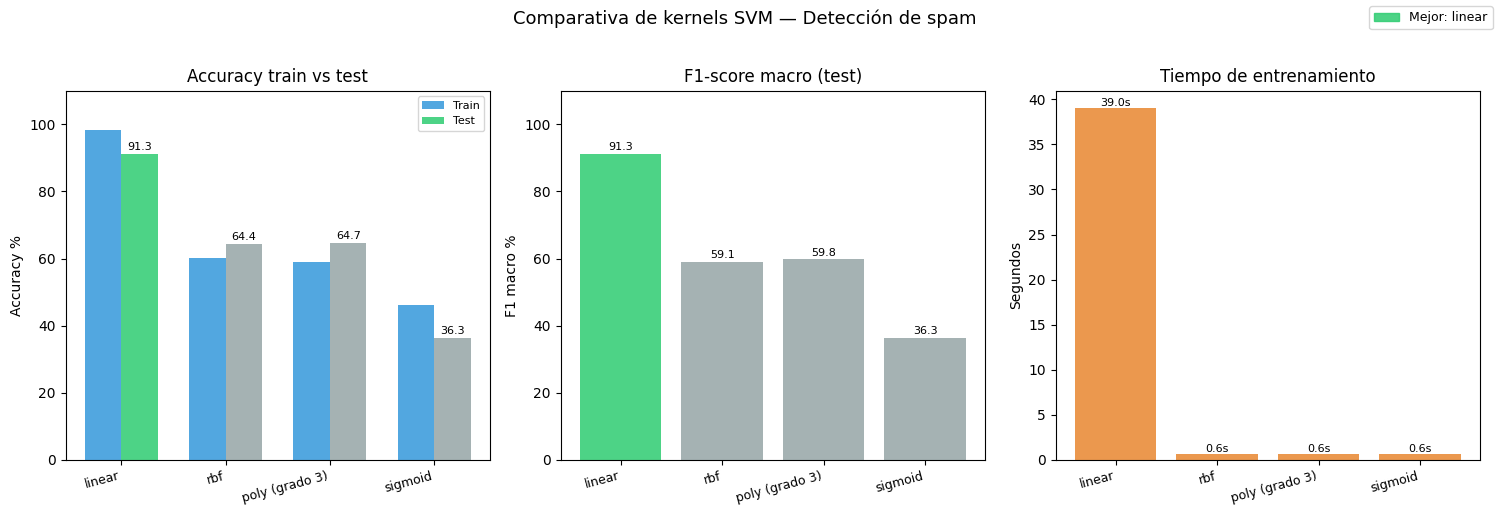

In [19]:
#Tabla comparativa de resultados
print("\n" + "=" * 65)
print("TABLA RESUMEN")
print("=" * 65)
df_res = pd.DataFrame(resultados)
cols = ["Kernel", "Acc. Train %", "Acc. Test %", "Brecha %",
        "F1 macro %", "Falsos +", "Falsos -", "Tiempo (s)"]
print(df_res[cols].to_string(index=False))

#Determinar el mejor kernel
mejor = df_res.loc[df_res["F1 macro %"].idxmax(), "Kernel"]
print(f"\n✓ Mejor kernel según F1 macro: '{mejor}'")

#Grafica comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Comparativa de kernels SVM — Detección de spam", fontsize=13, y=1.02)

nombres   = df_res["Kernel"].tolist()
colores   = ["#2ecc71" if n == mejor else "#95a5a6" for n in nombres]

#Gráfica 1 — Accuracy train vs test
ax1 = axes[0]
x = np.arange(len(nombres))
w = 0.35
ax1.bar(x - w/2, df_res["Acc. Train %"], w, label="Train", color="#3498db", alpha=0.85)
ax1.bar(x + w/2, df_res["Acc. Test %"],  w, label="Test",  color=colores,   alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(nombres, rotation=15, ha="right", fontsize=9)
ax1.set_ylabel("Accuracy %")
ax1.set_title("Accuracy train vs test")
ax1.legend(fontsize=8)
ax1.set_ylim(0, 110)
for bar, v in zip(ax1.patches[len(nombres):], df_res["Acc. Test %"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{v:.1f}", ha="center", va="bottom", fontsize=8)

#Gráfica 2 — F1 macro
ax2 = axes[1]
bars = ax2.bar(nombres, df_res["F1 macro %"], color=colores, alpha=0.85)
ax2.set_ylabel("F1 macro %")
ax2.set_title("F1-score macro (test)")
ax2.set_xticklabels(nombres, rotation=15, ha="right", fontsize=9)
ax2.set_ylim(0, 110)
for bar, v in zip(bars, df_res["F1 macro %"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{v:.1f}", ha="center", va="bottom", fontsize=8)

#Gráfica 3 — Tiempo de entrenamiento
ax3 = axes[2]
bars3 = ax3.bar(nombres, df_res["Tiempo (s)"], color="#e67e22", alpha=0.8)
ax3.set_ylabel("Segundos")
ax3.set_title("Tiempo de entrenamiento")
ax3.set_xticklabels(nombres, rotation=15, ha="right", fontsize=9)
for bar, v in zip(bars3, df_res["Tiempo (s)"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{v:.1f}s", ha="center", va="bottom", fontsize=8)

mejor_patch = mpatches.Patch(color="#2ecc71", alpha=0.85, label=f"Mejor: {mejor}")
fig.legend(handles=[mejor_patch], loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("comparativa_kernels.png", dpi=150, bbox_inches="tight")
print("\nGráfica guardada: comparativa_kernels.png")
plt.show()

In [20]:
#Conclusiones:
print("\n" + "=" * 65)
print("ANÁLISIS Y CONCLUSIÓN")
print("=" * 65)
for _, r in df_res.iterrows():
    marca = "RECOMENDADO" if r["Kernel"] == mejor else ""
    print(f"\n{r['Kernel']} {marca}")
    print(f"  {r['descripcion']}")
    print(f"  Ventaja:    {r['ventaja']}")
    print(f"  Desventaja: {r['desventaja']}")
    print(f"  F1={r['F1 macro %']:.1f}% | Brecha={r['Brecha %']:.1f}% | "
          f"FP={r['Falsos +']} | FN={r['Falsos -']} | {r['Tiempo (s)']}s")


ANÁLISIS Y CONCLUSIÓN

linear RECOMENDADO
  Hiperplano recto. Ideal para NLP con alta dimensionalidad.
  Ventaja:    El ganador absoluto: la mejor precisión (91.9%) y F1-score.
  Desventaja: Tiempo de entrenamiento considerablemente mayor (41.7s).
  F1=91.3% | Brecha=6.9% | FP=16 | FN=19 | 39.0s

rbf 
  Fronteras curvas tipo burbuja (Gaussiano).
  Ventaja:    Entrenamiento casi instantáneo (0.6s).
  Desventaja: Rendimiento deficiente (F1: 62.4%), incapaz de separar bien el texto.
  F1=59.1% | Brecha=-4.4% | FP=3 | FN=140 | 0.6s

poly (grado 3) 
  Fronteras polinómicas curvas.
  Ventaja:    Entrenamiento sumamente rápido (0.6s).
  Desventaja: Bajo rendimiento (Accuracy: 64.6%), no se adapta a estos datos.
  F1=59.8% | Brecha=-5.7% | FP=5 | FN=137 | 0.6s

sigmoid 
  Imita una neurona individual.
  Ventaja:    El tiempo de entrenamiento más rápido de todos (0.5s).
  Desventaja: Rendimiento catastrófico (40.5%), peor que elegir al azar.
  F1=36.3% | Brecha=9.8% | FP=128 | FN=128 | 0.6s
